# BERTopic for topic modelling

Welcome back! 
<br>

<img src="https://raw.githubusercontent.com/MaartenGr/BERTopic/master/images/logo.png" width="40%">

# RECAP

In the previous session, we worked with a dataset of tweets collected from the Office of the United Nations High Commissioner for Human Rights (2017–2022). The aim was not to test predefined categories, but to explore what themes emerge from the data using topic modelling.

We began by setting up the environment and downloading the dataset. Because the original file contained a formatting issue around a specific row, we imported it in two parts and reconstructed a clean version of the dataset. This step highlighted a practical point: real-world data often requires manual inspection and adjustment before analysis.

We then focused on text preprocessing. Rather than applying a single cleaning step, we constructed a pipeline of functions to:

remove emojis,
strip URLs and mentions,
clean hashtags,
remove noisy characters,
and standardise spacing.

This allowed us to move from raw social media text to a more consistent representation suitable for modelling.

After preprocessing, we filtered the dataset to English-language tweets and created a cleaned text column. These cleaned texts formed the input to our topic model.

We then introduced BERTopic and fitted the model using:

a sentence transformer (all-mpnet-base-v2) to generate embeddings,
UMAP to reduce dimensionality,
and a keyphrase-based vectorizer to improve topic representation.

This pipeline allowed us to move from individual tweets to clusters of semantically similar texts.

Finally, we explored the outputs of the model by:

inspecting topic frequencies,
examining top terms within topics,
and looking at representative documents.

At this stage, the focus was on understanding what the model produces and how topics are constructed.

# This Week...
In this session, we move from generating topics to working more closely with the model outputs.

We focus on how to interpret topics in a more systematic way, going beyond simple inspection of top words. This includes examining topic composition, comparing topics, and identifying patterns in how documents are grouped.

We also make use of visualisations to better understand the structure of the model and how topics relate to one another.

Finally, we consider ways to improve topic quality in practice. This includes adjusting model components and discussing extensions, such as adapting embedding models to better fit specific datasets.

# Reload Data and Model


In [4]:
# Install packages
!pip install bertopic sentence-transformers huggingface_hub==0.23.4 tokenizers keyphrase-vectorizers



In [5]:
# Reload data from GitHub
import pandas as pd
base_url = "https://raw.githubusercontent.com/DCS-training/TopicModellingBert/main/Data/"

df = pd.read_csv(base_url + "un_tweets_corrected.csv")
en_data = pd.read_csv(base_url + "english_data.csv")



/tmp/ipykernel_6372/436394819.py:5: DtypeWarning:

Columns (61,62,63,64,65,66,79,85) have mixed types. Specify dtype option on import or set low_memory=False.



In [ ]:
# Reload BERTopic model from Hugging Face
# The BERTopic model we trained last week is now available at a Huggingface Repository. Instead of rerunning the script in the first session, we download and load the model.

from huggingface_hub import hf_hub_download
from bertopic import BERTopic

# Download the model file from Hugging Face
model_path = hf_hub_download(
    repo_id="anonymousjqd/cdcs_BERTopic_models_2026",
    filename="bertopic_model"
)

# Load it
topic_model = BERTopic.load(model_path)



In [8]:
# If you run into issues with loading via Huggingface, you can retrain the model:
from bertopic import BERTopic
from umap import UMAP
from bertopic.vectorizers import KeyphraseCountVectorizer

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# NOTE: earlier versions of KeyphraseCountVectorizer do not use the `decay` and `delete_min_df` params
try: # works with KeyphraseCountVectorizer v0.13
    topic_model = BERTopic(embedding_model="all-mpnet-base-v2",
                           umap_model = umap_model,
                        language="english",
                        calculate_probabilities=True,
                        verbose=True,
                        vectorizer_model=KeyphraseCountVectorizer(max_df = int(0.5*len(docs)),
                                                                  min_df = 5, decay = 0.1, delete_min_df=5.0)
                        )
except TypeError: # in case of older version of KeyphraseCountVectorizer
    topic_model = BERTopic(embedding_model="all-mpnet-base-v2",
                           umap_model = umap_model,
                        language="english",
                        calculate_probabilities=True,
                        verbose=True,
                        vectorizer_model=KeyphraseCountVectorizer(max_df = int(0.5*len(docs)), min_df = 5)
                        )

topics, probs = topic_model.fit_transform(docs)

ImportError: cannot import name 'KeyphraseCountVectorizer' from 'bertopic.vectorizers' (/opt/conda/lib/python3.12/site-packages/bertopic/vectorizers/__init__.py)

# Interpreting Topics
Let's recheck how topics are distributed. We can start by looking at which topics are most frequent and how much of the data they capture.

In [6]:
# Overview of topics
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2093,-1_human rights_rights_human_amp,"[human rights, rights, human, amp, un, women, ...",[my experience has shown me that sustainable a...
1,0,246,0_racism_fightracism_racial discrimination_dis...,"[racism, fightracism, racial discrimination, d...",[racism plagues our world it is abhorrent it i...
2,1,171,1_myanmar_rohingya_bangladesh_military,"[myanmar, rohingya, bangladesh, military, retu...",[myanmar alongside episodic violence a campaig...
3,2,128,2_lgbti_love_lgbt_identity,"[lgbti, love, lgbt, identity, matter, gender, ...",[lets build a world where everyone is free equ...
4,3,116,3_hlpf_globalgoals_2030agenda_development,"[hlpf, globalgoals, 2030agenda, development, a...",[freedom of peaceful assembly and association ...
...,...,...,...,...,...
168,167,11,167_social protection_social security_protecti...,"[social protection, social security, protectio...",[food health education housing socialjusticeda...
169,168,11,168_languages_sign_signing_many ways,"[languages, sign, signing, many ways, ways, re...",[72 million people around the are deaf sundays...
170,169,11,169_brazil_survivor_amp children_stigma,"[brazil, survivor, amp children, stigma, end, ...",[brazil calls on the country to redouble effor...
171,170,11,170_environment_biodiversity_earthday_loss,"[environment, biodiversity, earthday, loss, u0...",[what if on this international motherearthdayu...


In [7]:
# Inspect a specific topic (keywords)
topic_model.get_topic(5)

[('territory', 0.033726594936390554),
 ('palestine', 0.03025744263728658),
 ('security forces', 0.019508495375520327),
 ('forces', 0.01795980794516173),
 ('zeid', 0.017037373332804067),
 ('security', 0.01623116917856609),
 ('demonstrators', 0.014624844214513546),
 ('un humanrights', 0.013635821307063744),
 ('east', 0.013541475143923554),
 ('killing', 0.013481934017310605)]

In [8]:
# Inspect representative documents
topic_model.get_representative_docs(5)

['end the occupation and the violence amp insecurity will largely disappear un humanrights chief delivers opening statement at special session on the human rights situation in the occupied palestinian territory full speech',
 'the occupation must end so the people of palestine can be liberated and the people of israel liberated from it end the occupation and the violence and insecurity will largely disappear un human rights chief zeid',
 'un human rights chief zeid truly shocked at killing of a wheelchairbound amputee by israeli security forces close to the fence between gaza and israel last friday']

# Comparing Topics

We can compare topics qualitatively by inspecting the keywords in each

In [9]:
topic_model.get_topic(3)

[('hlpf', 0.05004146263002477),
 ('globalgoals', 0.04928203433498935),
 ('2030agenda', 0.036259885565260094),
 ('development', 0.030816227283521926),
 ('agenda2030', 0.029275817899414677),
 ('poverty', 0.026387533624924804),
 ('participation', 0.022988239464158337),
 ('leavenoonebehind', 0.021858344308567004),
 ('progress', 0.020338650004003037),
 ('inequality', 0.016616297318628938)]

In [10]:
topic_model.get_topic(7)

[('syria', 0.14686639242481558),
 ('civilians', 0.05738523908322996),
 ('parties', 0.03542529435481989),
 ('hostilities', 0.026368164419960167),
 ('areas', 0.02274391373351326),
 ('civilian', 0.02085563303549061),
 ('weapons', 0.02072492544278093),
 ('attacks', 0.019479823843398112),
 ('conflict', 0.018954754707534792),
 ('fighting', 0.017816536006483554)]

In [11]:
topic_model.get_representative_docs(3)

['freedom of peaceful assembly and association are two key human rights necessary for achieving globalgoals un expert at hlpf provides practical recommendations for civil society participation in implementing 2030agenda standup4humanrights',
 'national action amp global partnerships are critical to achieve globalgoals through engagement of civil society orgs humanrights defenders amp citizens public participation is required by agenda2030 to leavenoonebehind it gives a voice to those who are excluded hlpf',
 'violations of humanrights impede sustainable development and undermine progress towards reaching the globalgoals report many countries to hlpf watch live standup4humanrights to help implement 2030agenda']

In [12]:
topic_model.get_representative_docs(7)

['syria the suffering of civilians in eastern ghouta is an outrage zeid',
 'is deeply concerned about violence in douma syria he calls on all parties to cease fighting it is critical that civilians be protected',
 'syria the syrian crisis is breaking our world']

## Concept ~ Topic
We can quantitatively inspect topics that have the closest similarity to a concept using BERTopic's built in similarity.


In [13]:
# Below is an example of how we can find topics that are closer to the concept of 'torture'.
similar_topics, similarity = topic_model.find_topics("torture", top_n=5)
similar_topics, similarity


([23, 99, 50, 109, 35],
 [0.6389424, 0.5219177, 0.5094832, 0.37657326, 0.37088197])

In [14]:
for topic in similar_topics:
    print(topic_model.get_topic(topic))

[('torture', 0.16556233261781642), ('fund', 0.06121871415857629), ('victims', 0.055616181724941274), ('survivors', 0.04128751070850736), ('voluntary fund', 0.03626861952486663), ('un torture fund', 0.03556482913526336), ('endtorture', 0.0310873881641714), ('redress', 0.02411108770964725), ('rehabilitation', 0.023171403478395212), ('illtreatment', 0.020730828867382634)]
[('prevention', 0.12982575603291452), ('body', 0.1285066708841044), ('torture', 0.1181066700204286), ('visits', 0.07431428904851596), ('endtorture', 0.05990260842265586), ('treatment', 0.055545912211099405), ('visit', 0.05134971427538693), ('liberty', 0.04883362457842954), ('illtreatment', 0.04793573718172197), ('torture amp illtreatment', 0.04215213169556283)]
[('torture', 0.061179992813820076), ('june', 0.04965955155094501), ('illtreatment', 0.037338483638405986), ('prison', 0.03667896662369982), ('friday', 0.0362929751400691), ('discussion', 0.033940827091938984), ('edt', 0.0329177161799277), ('detention', 0.031330180

Similarity scores can be interpreted as:
closer to 1-> very similar
closer to 0-> weak similarity

## Topic vs Topic
We can compare topics using a heatmap.

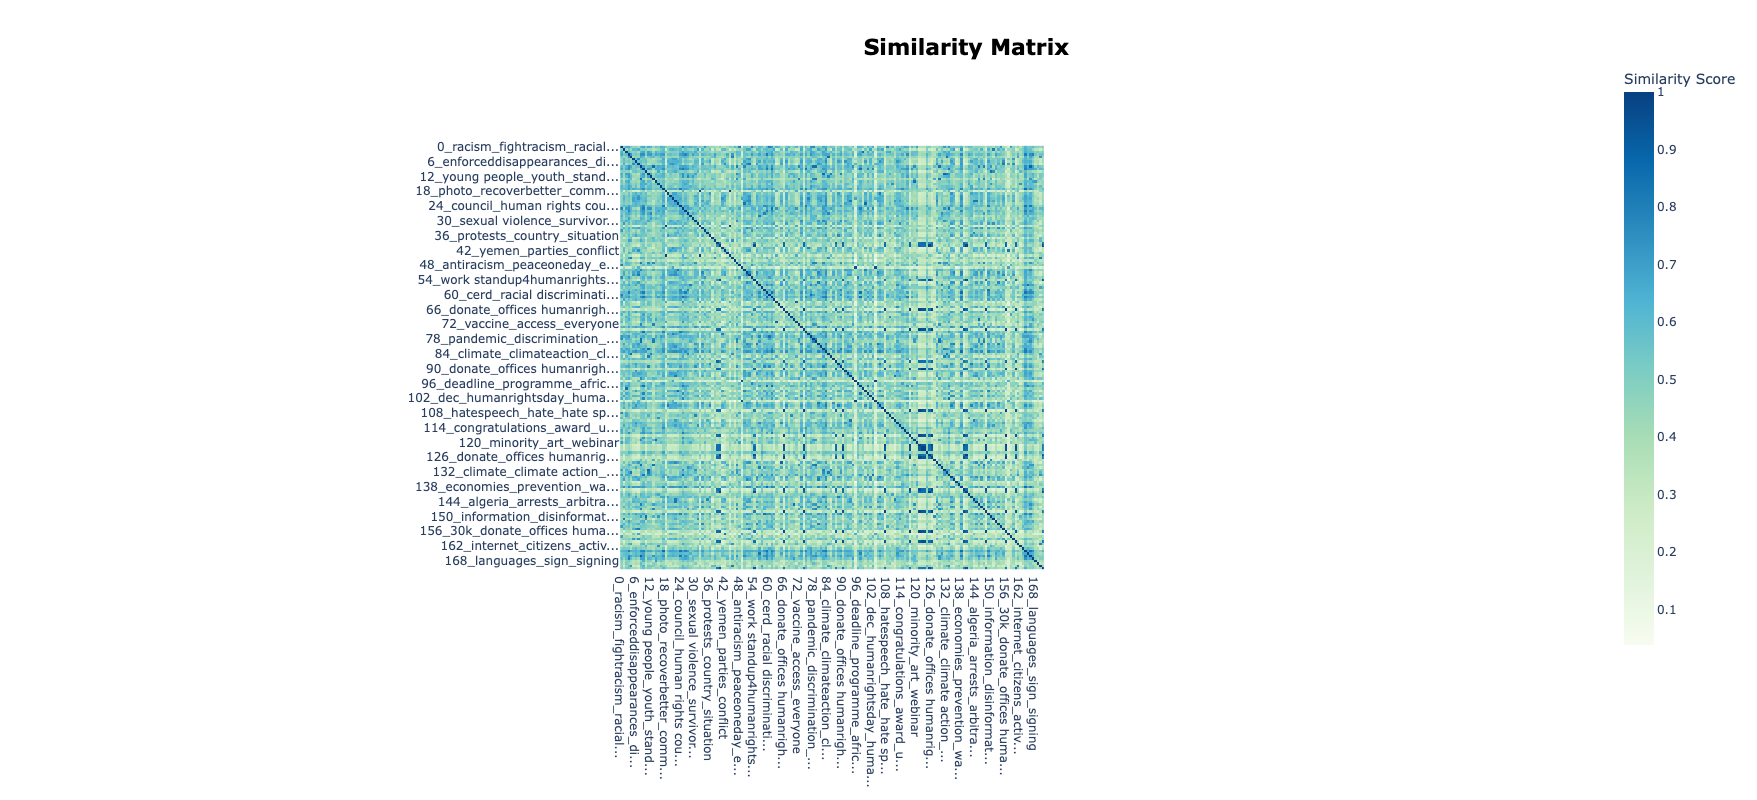

In [15]:
topic_model.visualize_heatmap()

We can also compare topics quantitatively by looking at their c-TF-IDF representations. Each topic is defined by a weighted set of words, and cosine similarity allows us to measure how similar these word distributions are.

This provides a more direct comparison of topics based on their defining terms, rather than relying only on visual inspection or broader semantic embeddings.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

# Get c-TF-IDF matrix
ctfidf = topic_model.c_tf_idf_

# Compare two topics
topic_a = 4
topic_b = 9

similarity = cosine_similarity( #Do these two topics rely on similar words, and with similar importance?
    ctfidf[topic_a],
    ctfidf[topic_b]
)

print(similarity)


[[0.21104896]]


# Visualisation

## Visualise Structure: Topic Map

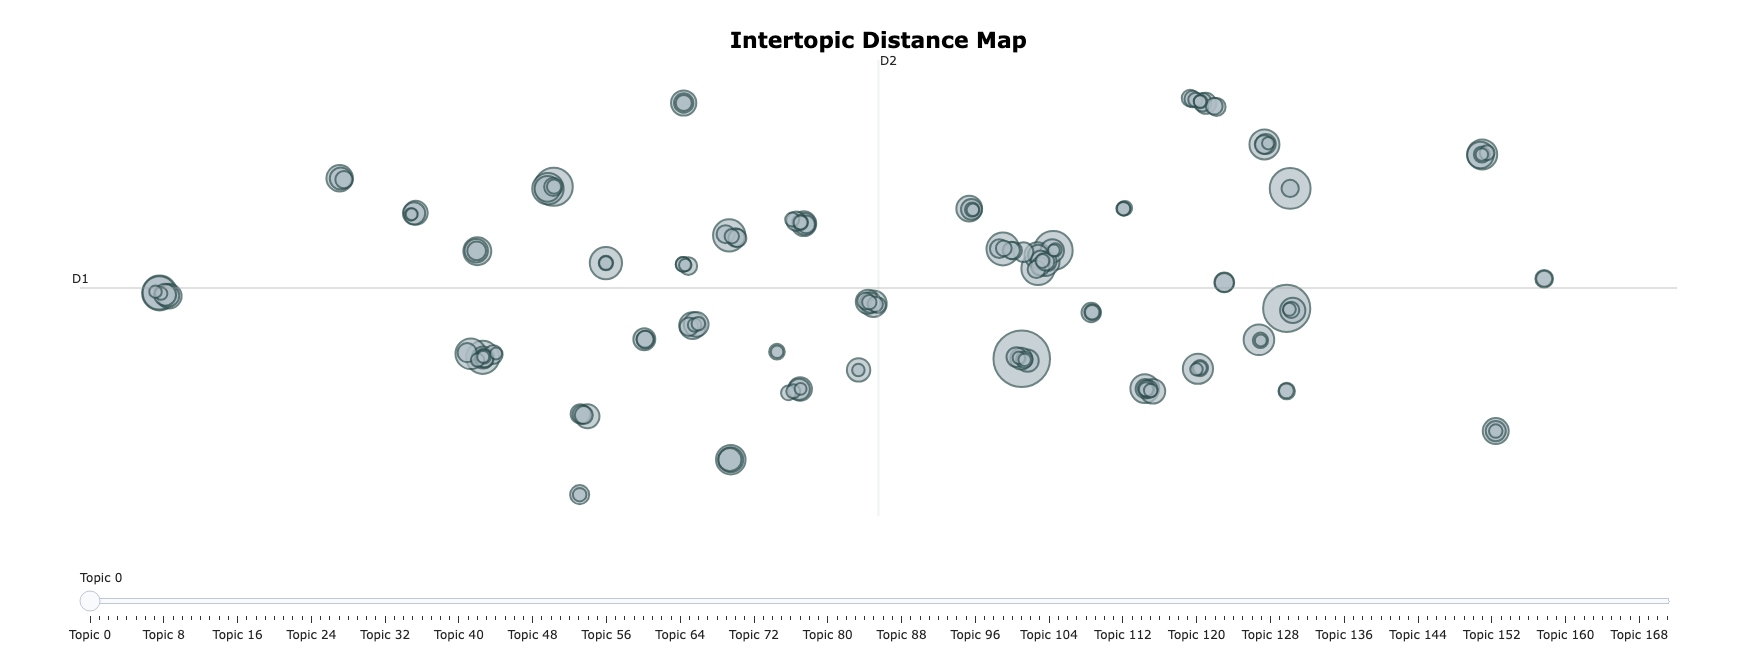

In [17]:
topic_model.visualize_topics()

## Visualise Representation :  Term Frequencies

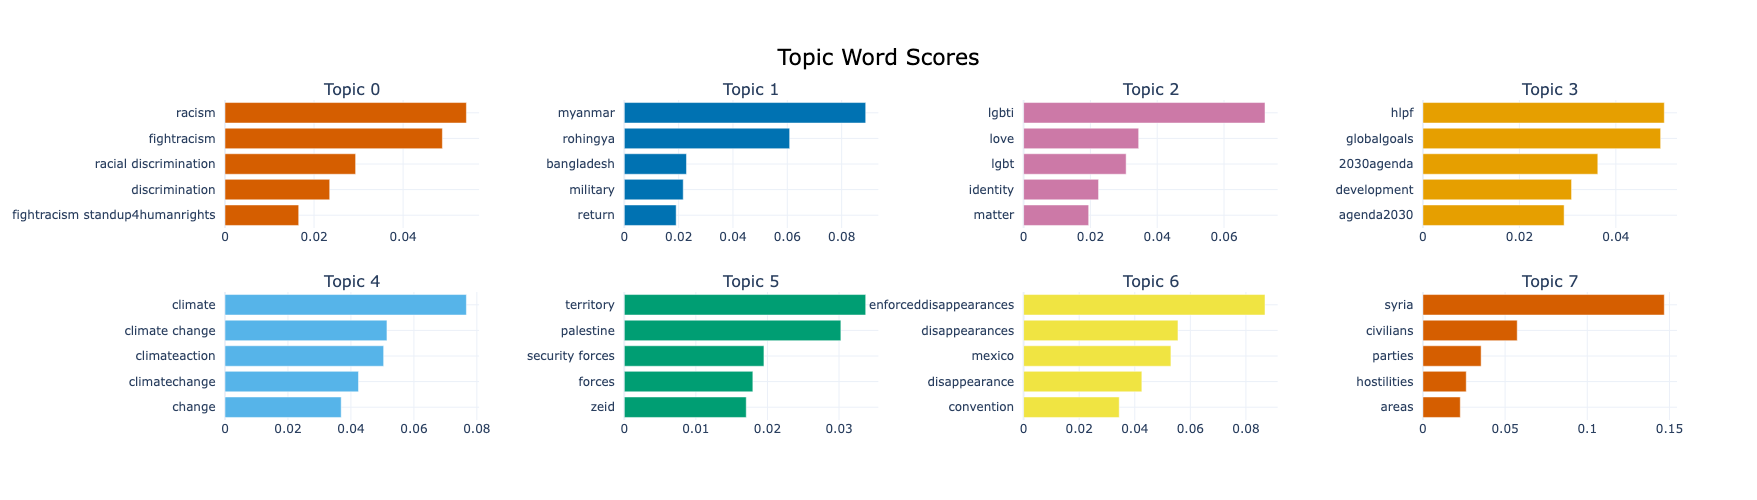

In [18]:
topic_model.visualize_barchart()

## Visualise Topics : Wordcloud

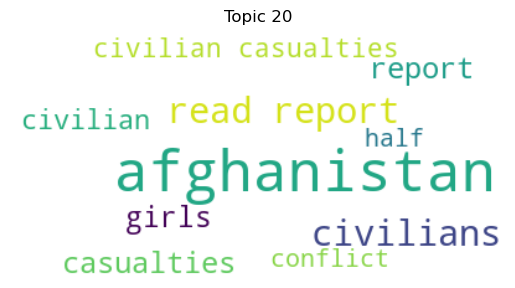

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Select a topic
topic_id = 20

# Get words and weights
topic_words = dict(topic_model.get_topic(topic_id))

# Create word cloud
wc = WordCloud(background_color="white")
wc.generate_from_frequencies(topic_words)

# Plot
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Topic {topic_id}")
plt.show()

## Visualize Topic Hierarchy
The topics that were created can be hierarchically reduced. In order to understand the potential hierarchical structure of the topics, we can use scipy.cluster.hierarchy to create clusters and visualize how they relate to one another. This might help selecting an appropriate nr_topics when reducing the number of topics that you have created.

In [3]:
topic_model.visualize_hierarchy()

ValueError: Distance matrix cannot contain negative values.

# Improving BERTopic

We can improve our topic model in several ways. These include reducing the number of topics, refining how topics are represented, and incorporating additional information such as annotated data. Before making any changes, however, we first need to identify where the model may be underperforming.

Potential issues to look for include topics that overlap in meaning, topics that are too broad or too specific, and topics that are difficult to interpret. We may also observe that some topics contain noisy or loosely related documents, suggesting that the clustering is not fully coherent. Identifying these issues allows us to make more targeted adjustments, rather than modifying the model arbitrarily.

## Topic Reduction

One common issue is that the model may generate too many topics, some of which capture very similar or overlapping content. This can make the results harder to interpret, as related themes are split across multiple topics rather than being grouped together. In such cases, topic reduction can be used to merge similar topics into broader, more coherent clusters. This helps simplify the structure of the model, making it easier to interpret while retaining the main themes present in the data.

To decide whether we should reduce the topics, we can inspect the heatmap.
If multiple topics are highliy similar, this suggests redundancy and indicates that topic reduction may be appropriate

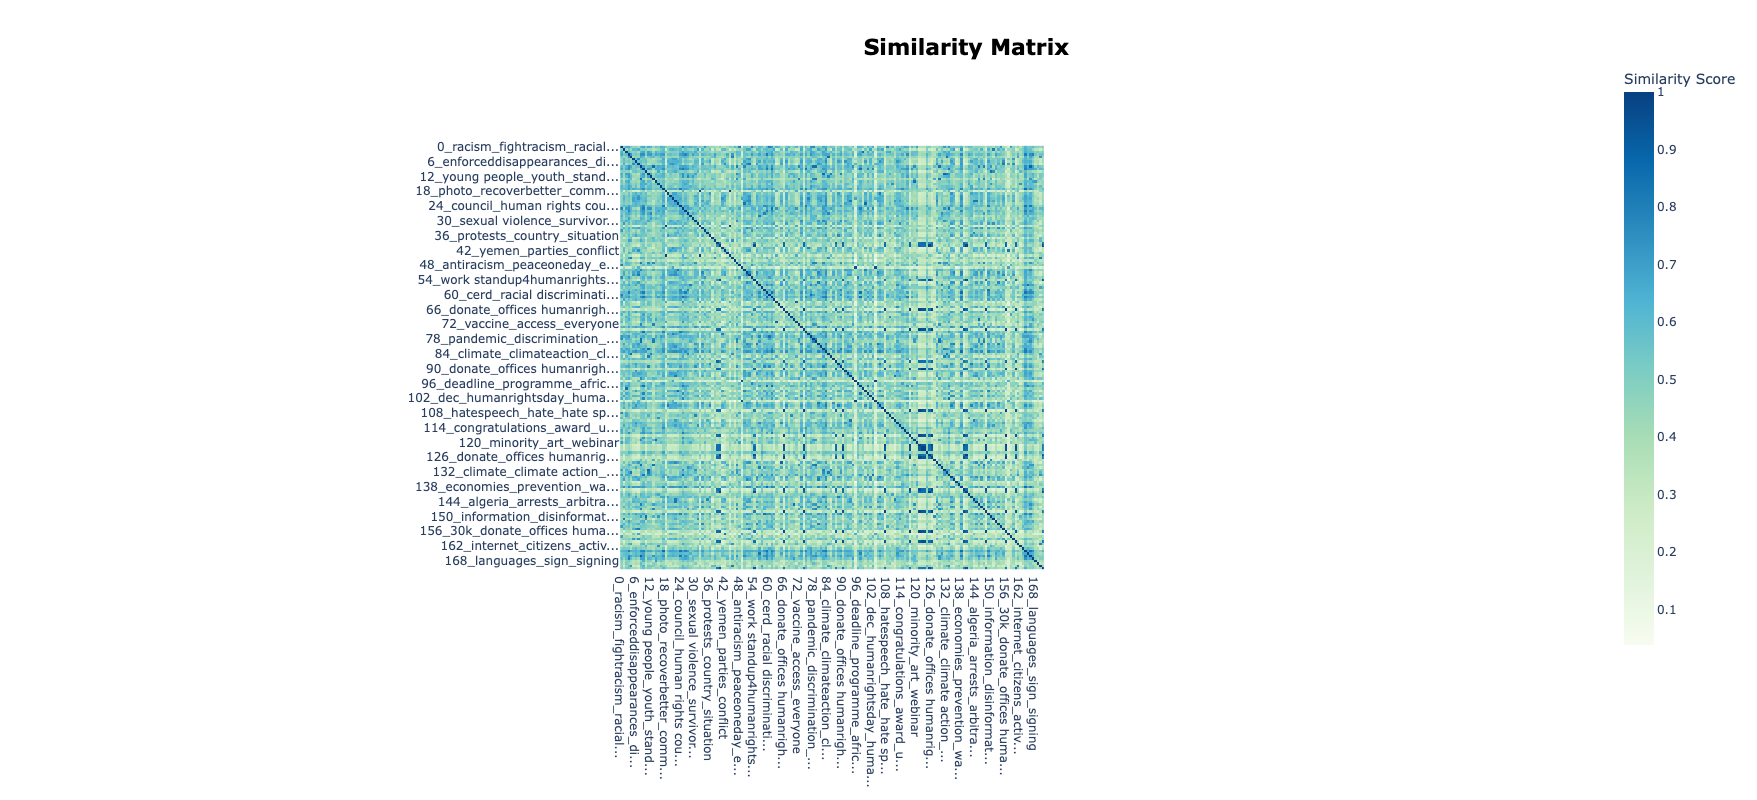

In [22]:
topic_model.visualize_heatmap()

In [ ]:
# Reducing Topics (DO NOT RUN without GPU)

docs = list(en_data["text_clean"])

# Reduce the number of topics
reduced_model = topic_model.reduce_topics(docs, nr_topics=30)

# Inspect the new topics
reduced_model.get_topic_info()

In [19]:
len(topic_model.get_topic_info())

30

Topic reduction modifies the model in place. To compare the model before and after reduction, we need to create a copy of the original model before applying the reduction step.

## Fine Tuning
Another way to improve our results is to fine-tune our model. Fine-tuning refers to adjusting the topic model to improve the quality and interpretability of the topics it produces. Rather than rebuilding the model from scratch, we refine its outputs by modifying how topics are represented or by incorporating additional information. This allows us to better align the model with the structure of the data or with specific research goals. 


In practice, fine-tuning can take several forms. For example, we may adjust how topics are grouped, refine their representations, or incorporate annotated data to guide the model towards more meaningful distinctions. These steps allow us to move from a purely unsupervised model to one that reflects more domain-specific knowledge.

### Guided Topic Modelling
One way to fine-tune a topic model is to guide it using domain knowledge. This can be done by specifying sets of seed words that represent themes we expect to find in the data. The model then uses these seed words to steer the formation of topics, resulting in more meaningful and interpretable clusters.

In [20]:
# Define Seed Topics:
seed_topic_list = [
    ["syria", "war", "civilians"],
    ["covid", "pandemic", "health"],
    ["women", "gender", "equality"],
    ["climate", "environment", "climate change"],
    ["torture", "detention", "disappearances"]
]

In [21]:
# Create Model with Seeds

topic_model_seeded = BERTopic(
    embedding_model="all-mpnet-base-v2",
    seed_topic_list=seed_topic_list,
    calculate_probabilities=True,
    verbose=True
)

In [4]:
# Fit Model (do not run without a GPU)
topics, probs = topic_model_seeded.fit_transform(docs)

NameError: name 'topic_model_seeded' is not defined

In [ ]:
# Save the Model
topic_model_seeded.save("bertopic_model_finetuned")